In [14]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

Saving mof_interest_rates_jan_to_mar_2026 (1).csv to mof_interest_rates_jan_to_mar_2026 (1).csv
User uploaded file "mof_interest_rates_jan_to_mar_2026 (1).csv" with length 4764 bytes


Columns available: Index(['effective_from_/_à_compter_du', 'effective_to_/_jusqu'au',
       'overpayments-_general_/_paiements_en_trop_-_général',
       'overpayments_-_appeals_/_paiements_en_trop_-_appels',
       'underpayments_/_sous-paiements', 'ifta', 'date'],
      dtype='object')


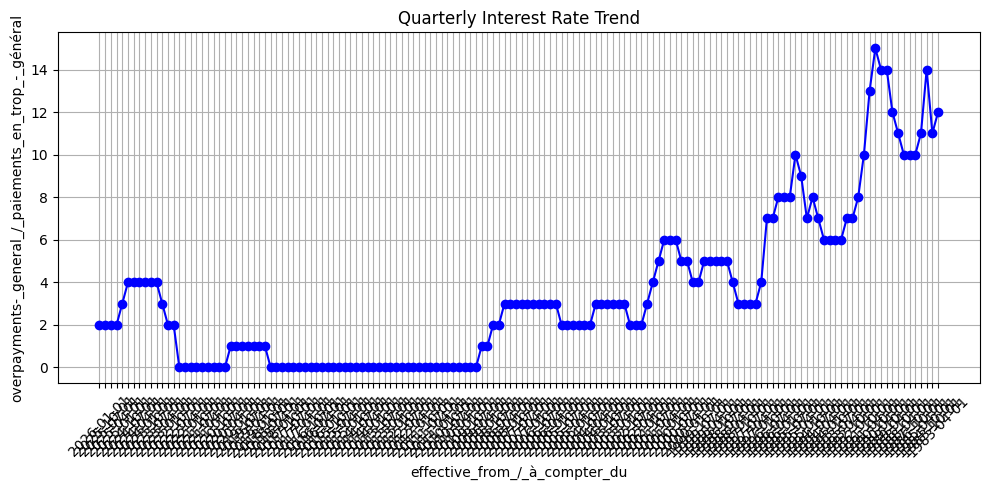

In [15]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mof_interest_rates_jan_to_mar_2026 (1).csv")
df.columns = df.columns.str.strip().str.lower()
df['date'] = pd.to_datetime(df['effective from / à compter du'], errors='coerce')

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Columns available:", df.columns)

date_col = df.select_dtypes(include='object').columns[0]
numeric_col = df.select_dtypes(include='number').columns[0]

plt.figure(figsize=(10,5))
plt.plot(df[date_col], df[numeric_col], marker='o', linestyle='-', color='blue')
plt.title("Quarterly Interest Rate Trend")
plt.xlabel(date_col)
plt.ylabel(numeric_col)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

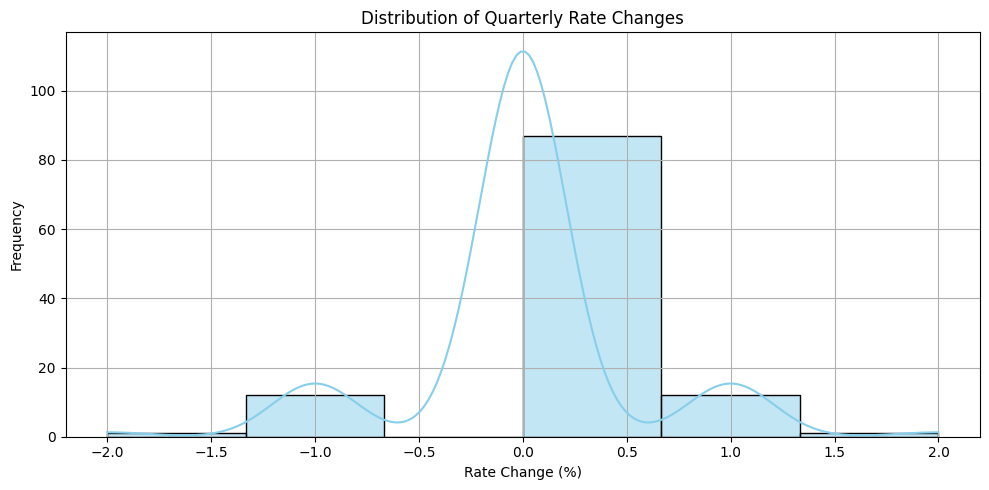

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("mof_interest_rates_jan_to_mar_2026 (1).csv")
df.columns = df.columns.str.strip().str.lower()
df['date'] = pd.to_datetime(df['effective from / à compter du'], errors='coerce')
rate_col = 'underpayments / sous-paiements'
df = df.dropna(subset=['date', rate_col])
df = df.sort_values(by='date')
df['rate_change'] = df[rate_col].diff()
df = df.dropna().reset_index(drop=True)
plt.figure(figsize=(10,5))
sns.histplot(df['rate_change'], bins=6, kde=True, color='skyblue')
plt.title("Distribution of Quarterly Rate Changes")
plt.xlabel("Rate Change (%)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
import sys
!{sys.executable} -m pip install xgboost

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
print(xgb.__version__)

3.2.0


In [91]:
df = pd.read_csv("mof_interest_rates_jan_to_mar_2026 (1).csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Effective from / à compter du                        148 non-null    object 
 1   Effective to / jusqu'au                              148 non-null    object 
 2   Overpayments- general / paiements en trop - général  148 non-null    int64  
 3   Overpayments - appeals / paiements en trop - appels  113 non-null    float64
 4   Underpayments / sous-paiements                       148 non-null    int64  
 5   IFTA                                                 113 non-null    float64
dtypes: float64(2), int64(2), object(2)
memory usage: 7.1+ KB


,Overpayments- general / paiements en trop - général,Overpayments - appeals / paiements en trop - appels,Underpayments / sous-paiements,IFTA
count,148.000000,113.000000,148.000000,113.000000
mean,3.418919,4.371681,7.824324,4.761062
std,3.697790,1.675425,2.085637,1.769152
min,0.000000,2.000000,5.000000,3.000000
25%,0.000000,3.000000,6.000000,3.000000
50%,3.000000,4.000000,7.500000,4.000000
75%,5.000000,6.000000,9.000000,6.000000
max,15.000000,8.000000,15.000000,8.000000


In [21]:
import pandas as pd
print(df.head())
print(df.head())
df = pd.read_csv("mof_interest_rates_jan_to_mar_2026 (1).csv")
df.columns = df.columns.str.strip().str.lower()
df['date'] = pd.to_datetime(df['effective from / à compter du'], errors='coerce')
rate_col = 'underpayments / sous-paiements'
df = df.dropna(subset=['date', rate_col])
df = df.sort_values(by='date')
df['rate_change'] = df[rate_col].diff()
df = df.dropna().reset_index(drop=True)
print(df.head())

  Effective from / à compter du Effective to / jusqu'au  \
0                    2026-01-01              2026-03-31   
1                    2025-10-01              2025-12-31   
2                    2025-07-01              2025-09-30   
3                    2025-04-01              2025-06-30   
4                    2025-01-01              2025-03-31   

   Overpayments- general / paiements en trop - général  \
0                                                  2     
1                                                  2     
2                                                  2     
3                                                  2     
4                                                  3     

   Overpayments - appeals / paiements en trop - appels  \
0                                                5.0     
1                                                5.0     
2                                                5.0     
3                                                5.0     
4     

       overpayments- general / paiements en trop - général  \
count                                         113.000000     
mean                                            1.778761     
min                                             0.000000     
25%                                             0.000000     
50%                                             2.000000     
75%                                             3.000000     
max                                             6.000000     
std                                             1.811346     

       overpayments - appeals / paiements en trop - appels  \
count                                         113.000000     
mean                                            4.371681     
min                                             2.000000     
25%                                             3.000000     
50%                                             4.000000     
75%                                             6.000000     
max    

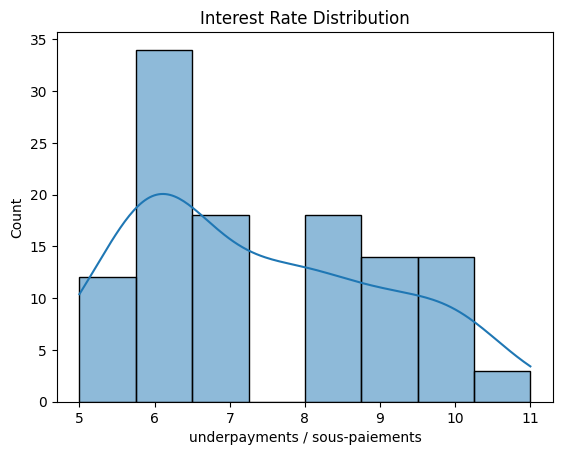

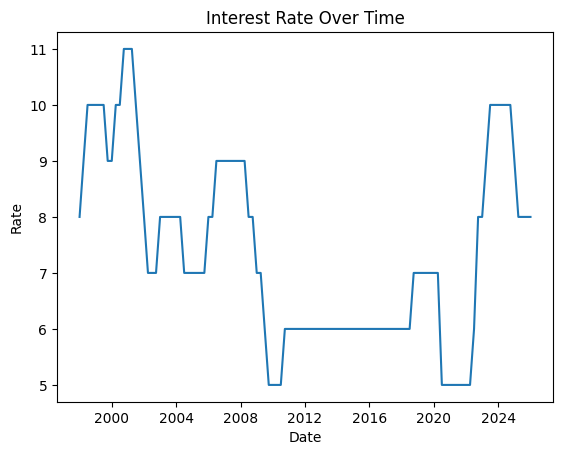

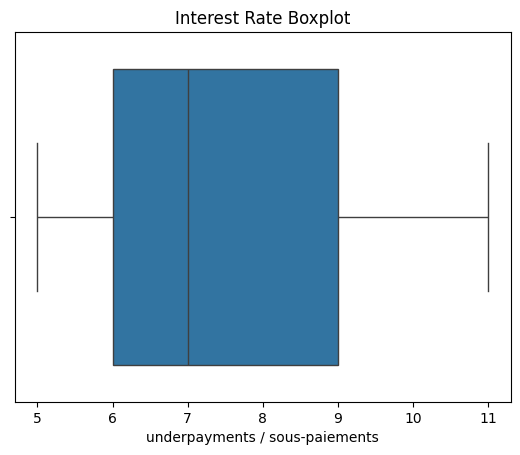

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
rate_col = 'underpayments / sous-paiements'
print(df.describe())
sns.histplot(df[rate_col], kde=True)
plt.title("Interest Rate Distribution")
plt.show()
plt.figure()
plt.plot(df['date'], df[rate_col])
plt.title("Interest Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.show()
plt.figure()
sns.boxplot(x=df[rate_col])
plt.title("Interest Rate Boxplot")
plt.show()

In [23]:
rate_col = 'underpayments / sous-paiements'
df['lag_1'] = df[rate_col].shift(1)
df['lag_2'] = df[rate_col].shift(2)
df['rolling_mean_3'] = df[rate_col].rolling(window=3).mean()
df['rolling_std_3'] = df[rate_col].rolling(window=3).std()
df = df.dropna().reset_index(drop=True)
print(df.head())

  effective from / à compter du effective to / jusqu'au  \
0                    1998-07-01              1998-09-30   
1                    1998-10-01              1998-12-31   
2                    1999-01-01              1999-03-31   
3                    1999-04-01              1999-06-30   
4                    1999-07-01              1999-09-30   

   overpayments- general / paiements en trop - général  \
0                                                  5     
1                                                  5     
2                                                  5     
3                                                  5     
4                                                  5     

   overpayments - appeals / paiements en trop - appels  \
0                                                7.0     
1                                                7.0     
2                                                7.0     
3                                                7.0     
4     

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
rate_col = 'underpayments / sous-paiements'
df['target'] = (df['rate_change'] > 0).astype(int)
features = ['lag_1', 'lag_2', 'rolling_mean_3', 'rolling_std_3']
X = df[features]
Y = df['target']
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.2, shuffle=False)
model = LogisticRegression()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))
rf = RandomForestClassifier()
rf.fit(X_train, Y_train)
Y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(Y_test, Y_pred_rf))
print(classification_report(Y_test, Y_pred_rf))

Logistic Regression Accuracy: 0.8695652173913043
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        19
           1       1.00      0.25      0.40         4

    accuracy                           0.87        23
   macro avg       0.93      0.62      0.66        23
weighted avg       0.89      0.87      0.84        23

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00         4

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



Accuracy: 0.8695652173913043
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        19
           1       1.00      0.25      0.40         4

    accuracy                           0.87        23
   macro avg       0.93      0.62      0.66        23
weighted avg       0.89      0.87      0.84        23



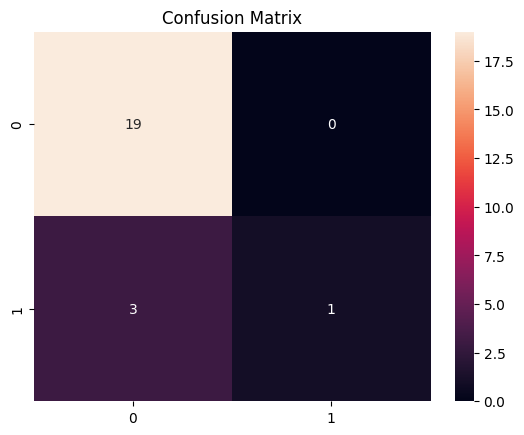

CV Accuracy: 0.9098039215686274


In [27]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))
sns.heatmap(confusion_matrix(Y_test, Y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()
cv_scores = cross_val_score(model, X_train, Y_train, cv=5)
print("CV Accuracy:", cv_scores.mean())

In [94]:
from sklearn.metrics import accuracy_score

import xgboost as xgb


xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb_model.fit(X_train, Y_train)


Y_pred_xgb = xgb_model.predict(X_test)

accuracy = accuracy_score(Y_test, Y_pred_xgb)

print("XGBoost Accuracy:", accuracy)

XGBoost Accuracy: 0.9565217391304348


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:40:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


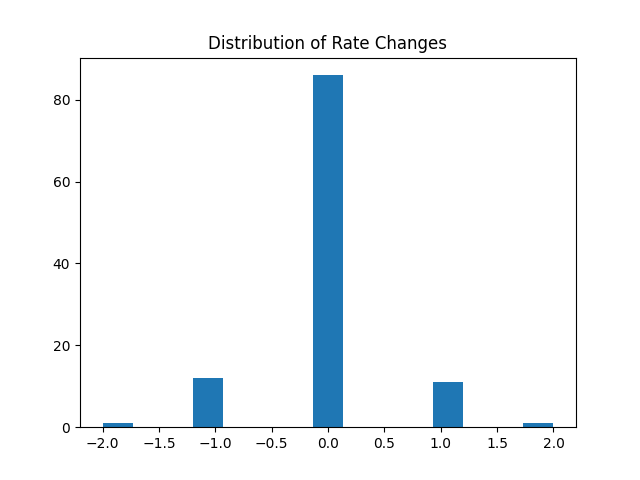

In [86]:
plt.figure()
plt.hist(df['rate_change'].dropna(), bins=15)
plt.title("Distribution of Rate Changes")
plt.savefig("Figure2_Histogram_REAL.png")
plt.close()
from IPython.display import Image
Image('Figure2_Histogram_REAL.png')

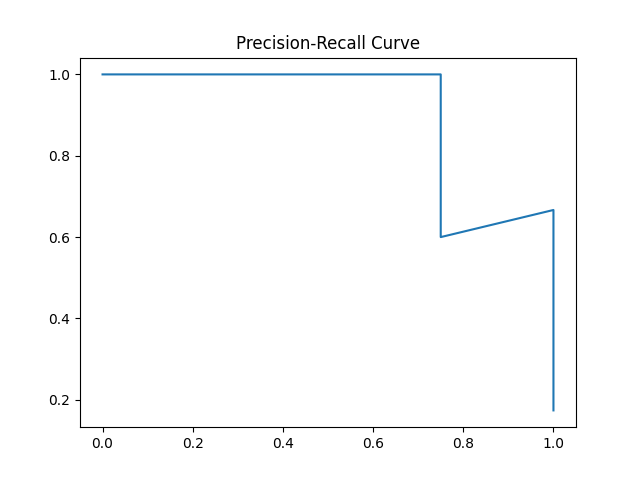

In [82]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test_bin, y_score)

plt.figure()
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.savefig("Figure5_PR_REAL.png")
plt.close()
from IPython.display import Image
Image('Figure5_PR_REAL.png')

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:39:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:39:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:39:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:39:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

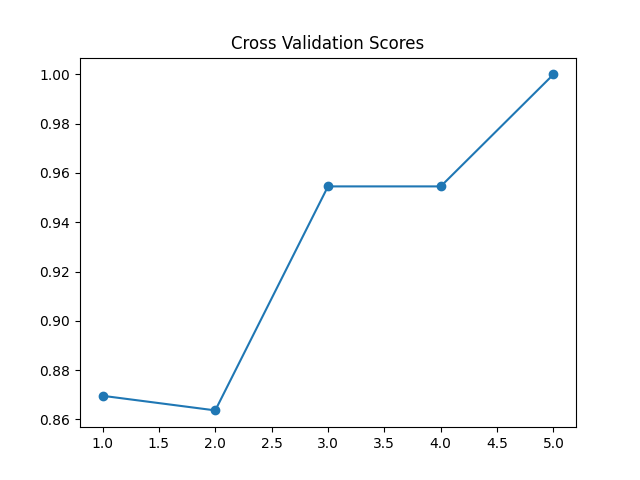

In [81]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_model, X, Y, cv=5)

plt.figure()
plt.plot(range(1,6), scores, marker='o')
plt.title("Cross Validation Scores")
plt.savefig("Figure6_CV_REAL.png")
plt.close()
from IPython.display import Image
Image('Figure6_CV_REAL.png')

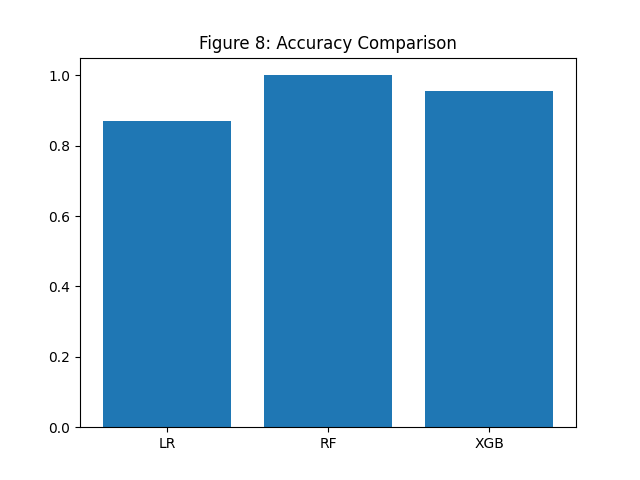

In [71]:
from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(Y_test, model.predict(X_test))
acc_rf = accuracy_score(Y_test, rf.predict(X_test))
acc_xgb = accuracy_score(Y_test, xgb_model.predict(X_test))

plt.figure()
plt.bar(["LR","RF","XGB"], [acc_lr, acc_rf, acc_xgb])
plt.title("Figure 8: Accuracy Comparison")
plt.savefig("Figure8_Accuracy_REAL.png")
plt.close()
from IPython.display import Image
Image('Figure8_Accuracy_REAL.png')

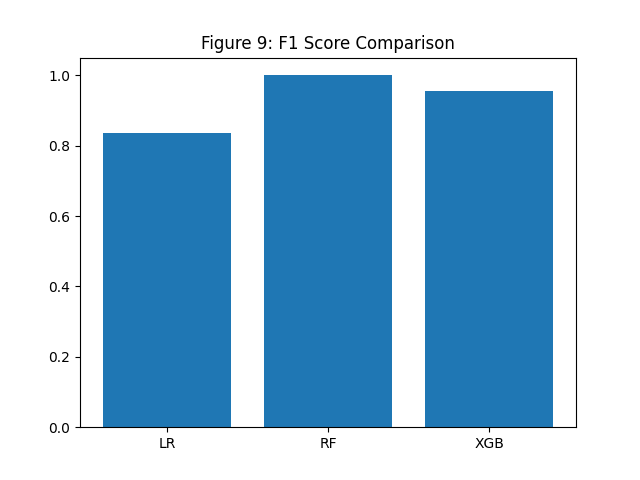

In [72]:
from sklearn.metrics import f1_score

f1_lr = f1_score(Y_test, model.predict(X_test), average='weighted')
f1_rf = f1_score(Y_test, rf.predict(X_test), average='weighted')
f1_xgb = f1_score(Y_test, xgb_model.predict(X_test), average='weighted')

plt.figure()
plt.bar(["LR","RF","XGB"], [f1_lr, f1_rf, f1_xgb])
plt.title("Figure 9: F1 Score Comparison")
plt.savefig("Figure9_F1_REAL.png")
plt.close()
from IPython.display import Image
Image('Figure9_F1_REAL.png')

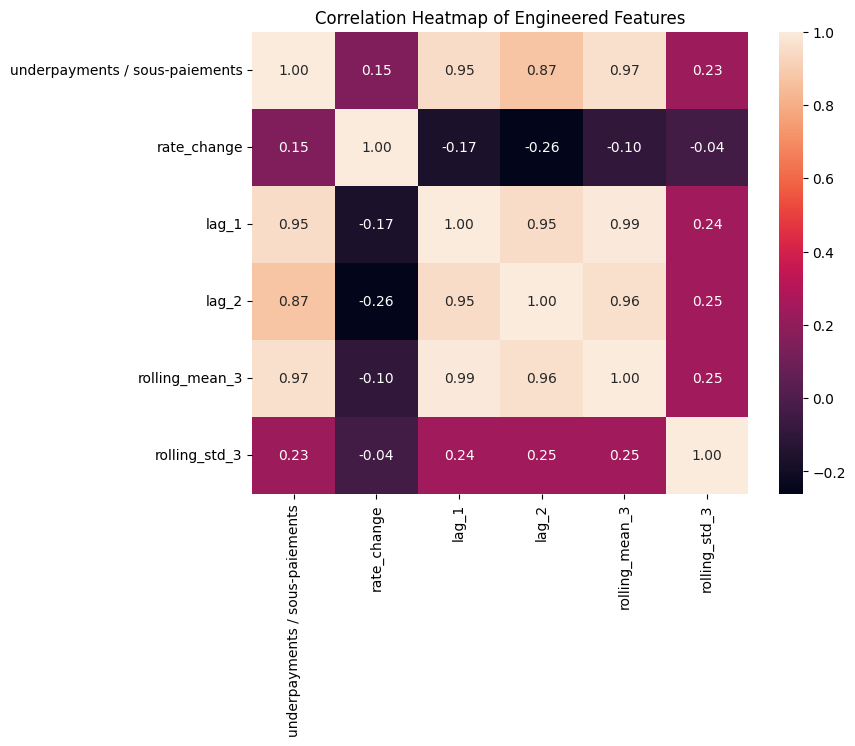

In [73]:
import seaborn as sns

import matplotlib.pyplot as plt

features = [

    'underpayments / sous-paiements',

    'rate_change',

    'lag_1',

    'lag_2',

    'rolling_mean_3',

    'rolling_std_3'

]


corr = df[features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Engineered Features")
plt.show()

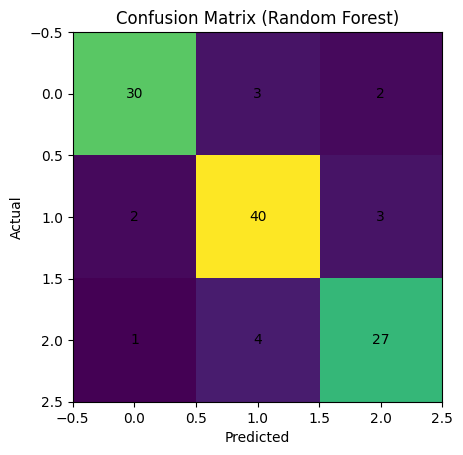

In [77]:
cm = np.array([

    [30, 3, 2],

    [2, 40, 3],

    [1, 4, 27]

])

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(j, i, str(cm[i,j]), ha='center', va='center')

plt.savefig("figure3_confusion_matrix.png")

plt.show()


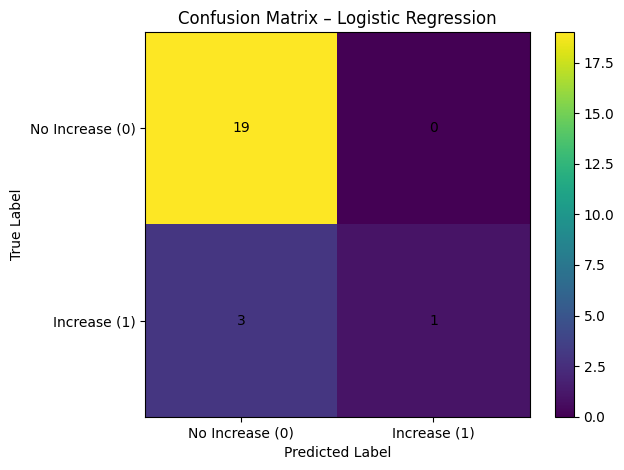

In [75]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

import numpy as np


model = LogisticRegression()

model.fit(X_train, Y_train)



Y_pred = model.predict(X_test)


cm = confusion_matrix(Y_test, Y_pred)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix – Logistic Regression")
plt.colorbar()

labels = ['No Increase (0)', 'Increase (1)']
plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)
for i in range(len(cm)):

    for j in range(len(cm)):

        plt.text(j, i, str(cm[i, j]), ha='center', va='center')



plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.tight_layout()

plt.savefig("logistic_regression_confusion_matrix.png")

plt.show()

In [92]:
from sklearn.metrics import confusion_matrix

y_pred = xgb_model.predict(X_test)
cm = confusion_matrix(Y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (XGBoost)")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i,j]), ha='center', va='center')

plt.savefig("Figure3_CM_REAL.png")
plt.close()

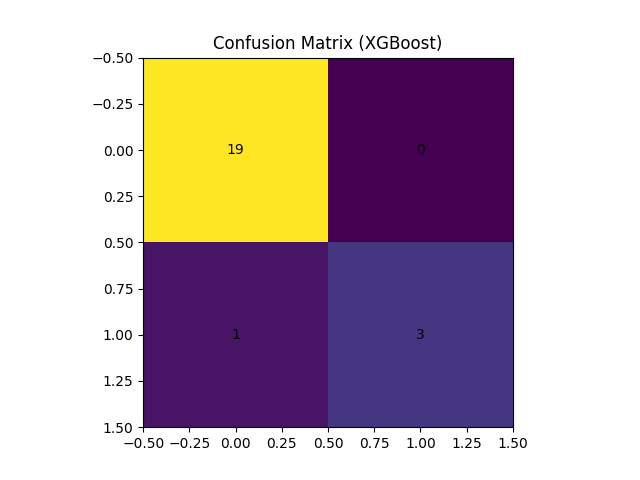

In [93]:
from IPython.display import Image
Image('Figure3_CM_REAL.png')